In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    classification_report, mean_squared_error,
    precision_recall_fscore_support
)
from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from collections import OrderedDict

%precision 3
pd.set_option('display.precision', 3)
np.set_printoptions(suppress=True, precision=3)

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    classification_report, mean_squared_error,
    precision_recall_fscore_support
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from collections import OrderedDict

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

%precision 3
pd.set_option('display.precision', 3)
np.set_printoptions(suppress=True, precision=3)

import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2


import sys

import os
# Add the project root to the Python path
sys.path.append(os.path.abspath('..'))


import lib.helper_fun 


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

In [3]:

import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Test train split

In [4]:

data = pd.read_csv('data.csv')
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

X_train, X_valid, y_train, y_valid = lib.helper_fun.random_split(data, label_col= "is_relevant")



In [5]:
print(f'train: {y_train.shape}')
print(y_train.value_counts(normalize=True))
print(f'test: {y_valid.shape}')
print(y_valid.value_counts(normalize=True))


train: (4789,)
is_relevant
0    0.821
1    0.179
Name: proportion, dtype: float64
test: (1198,)
is_relevant
0    0.821
1    0.179
Name: proportion, dtype: float64


# feature definitions 

In [6]:
data.columns

Index(['url', 'datetime', 'language', 'description', 'article_text', 'source',
       'is_relevant', 'used_description_as_text', 'extracted_entities',
       'entity_relationships', 'has_entities', 'has_relationships',
       'has_people', 'has_organizations', 'news_org', 'url_slug_title', 'date',
       'day_of_week', 'month', 'is_weekend', 'days_until_us_election',
       'days_until_french_election', 'days_until_german_election',
       'word_count', 'sentence_count', 'avg_sentence_length', 'noun_count',
       'verb_count', 'contains_question', 'quote_count', 'contains_number',
       'capital_ratio', 'mentions_social_media', 'article_type',
       'election_keyword_count', 'triggered_keyword',
       'mentions_election_keywords', 'election_certainty', 'no_title',
       'L_n_total_entities', 'L_n_people', 'L_n_locations',
       'L_n_relationships', 'L_n_institutions', 'L_num_title_words',
       'L_named_entity_density', 'L_avg_sentiment_polarity'],
      dtype='object')

In [7]:
drop_columns = [
    "datetime",   
    "date",                 # converted to time deltas
    "description",          # redundant fallback for text
    "article_text",         # too large for tabular use
    "url_slug_title",       # raw text (used already to create other features)
    "article_type", 
    "extracted_entities",
    "entity_relationships"
]

# Drop the columns from data
data = data.drop(columns=drop_columns, errors="ignore")

# Set the URL as the index
data = data.set_index("url")

In [8]:
target_column = "is_relevant"  

baseline_features = [
    "election_keyword_count",
    "days_until_us_election",
    "days_until_french_election",
    "days_until_german_election"
]

all_features = [col for col in data.columns if col != target_column]

llm_features = [
    col for col in data.columns if col.startswith("L_")
] + ['has_entities', 'has_relationships', 'has_people', 'has_organizations']

non_llm_features = [
    col for col in data.columns
    if col not in llm_features and col != target_column
]

#metadata_features = [col for col in df_featurized.columns if col.startswith("P_")]

all_features_with_llm = non_llm_features + llm_features
all_features_with_metadata = non_llm_features #+ metadata_features
all_features_full = non_llm_features + llm_features #+ metadata_features

categorical_features = [
    "language",              
    "source",                
    "day_of_week",  
    "month",         
    "triggered_keyword",     
    "news_org"               
]

binary_flags = [
    "is_weekend", "contains_question", "contains_number",
    "mentions_social_media", "mentions_election_keywords",
    "no_title", "used_description_as_text"
]

In [9]:
collector = lib.helper_fun.ResultCollector()
results = []
best_models = {} 

# Pipeline defintions

In [15]:
# ✅ Logit pipeline
pipe_logit = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(
        estimator=LogisticRegression(
            penalty='l1',
            solver='liblinear',  # required for L1
            max_iter=1000, 
            random_state=SEED
        )
    ))
])

pipe_logit1 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(
        estimator=LogisticRegression(
            penalty='l1',
            solver='liblinear',  # required for L1
            max_iter=1000, 
            random_state=SEED
        )
    ))
])

pipe_logit2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(
        estimator=LogisticRegression(
            penalty='l1',
            solver='liblinear',  # required for L1
            max_iter=1000, 
            random_state=SEED
        )
    ))
])

# ✅ Random Forest pipeline
pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=RandomForestClassifier(verbose=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_rf2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=RandomForestClassifier(verbose=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

# ✅ XGBoost pipeline
pipe_xgb_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_smote_pca = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_calibrated_select_features = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('select_features', SelectKBest(score_func=f_classif, k=30)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_new_smote = Pipeline([
    ('smote', SMOTE(
            random_state=42,
            sampling_strategy=0.40,  # Oversample until minority is 25% of majority class
            k_neighbors=3)),
    ('calibrated_model', CalibratedClassifierCV(
        estimator=XGBClassifier(verbosity=0, random_state=SEED),
        cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

####
pipe_xgb_smote2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_smote_pca2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_calibrated_select_features2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('select_features', SelectKBest(score_func=f_classif, k=30)),
    ('calibrated_model', CalibratedClassifierCV(estimator=XGBClassifier(verbosity=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_xgb_new_smote2 = Pipeline([
    ('smote', SMOTE(
            random_state=42,
            sampling_strategy=0.40,  # Oversample until minority is 25% of majority class
            k_neighbors=3)),
    ('calibrated_model', CalibratedClassifierCV(
        estimator=XGBClassifier(verbosity=0, random_state=SEED),
        cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])


# ✅ CatBoost pipeline
pipe_cat = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator= CatBoostClassifier(verbose=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

pipe_cat2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('calibrated_model', CalibratedClassifierCV(estimator= CatBoostClassifier(verbose=0, random_state=SEED),
                                                cv=KFold(n_splits=5, shuffle=True, random_state=42)))
])

# # ✅ Neural Network pipeline
# pipe_mlp = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('calibrated_model', CalibratedClassifierCV(method='isotonic',
#         estimator=MLPClassifier(
#     max_iter=1000,
#     early_stopping=True,
#     random_state=42),
#     cv=KFold(n_splits=5, shuffle=True, random_state=42
#     )))
# ])    

# pipe_mlp2 = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('calibrated_model', CalibratedClassifierCV(method='isotonic',
#         estimator=MLPClassifier(
#     max_iter=1000,
#     early_stopping=True,
#     random_state=42),
#     cv=KFold(n_splits=5, shuffle=True, random_state=42
#     )))
# ])     

# param grid setup 

In [11]:
logit_param_grid = {
    "calibrated_model__estimator__C": [0.1, 1.0],
    "calibrated_model__estimator__penalty": ["l1"]
}

rf_param_grid = {
    "calibrated_model__estimator__n_estimators": [100, 200, 500],
    "calibrated_model__estimator__max_depth": [3, 5, 10],
    "calibrated_model__estimator__min_samples_split": [2, 5, 10],
    "calibrated_model__estimator__criterion": ["gini", "entropy"]
}

xgb_param_grid = {
    "calibrated_model__estimator__learning_rate": [0.05, 0.1],
    "calibrated_model__estimator__max_depth": [5, 10, 15],
    "calibrated_model__estimator__n_estimators": [100, 200, 500],
    "calibrated_model__estimator__subsample": [0.8, 1.0],
    "calibrated_model__estimator__colsample_bytree": [0.8, 1.0]
}


catboost_param_grid = {
    "calibrated_model__estimator__learning_rate": [0.05, 0.1],
    "calibrated_model__estimator__depth": [5, 10, 15],
    "calibrated_model__estimator__iterations": [100, 200, 500],
    "calibrated_model__estimator__l2_leaf_reg": [1, 3, 5],
    "calibrated_model__estimator__border_count": [32, 64, 128]
}


# mlp_param_grid = {
#     "calibrated_model__estimator__hidden_layer_sizes": [(100,), (50, 50)],
#     "calibrated_model__estimator__alpha": [0.0001, 0.001],
#     "calibrated_model__estimator__learning_rate_init": [0.001, 0.01]
# }

# cost function

In [12]:
FN_COST = 4   # False Negative: Missed election-relevant article
FP_COST = 1   # False Positive: Article wrongly flagged as relevant

# running the models 

## logit 

🔍 Running model: Logit-Baseline


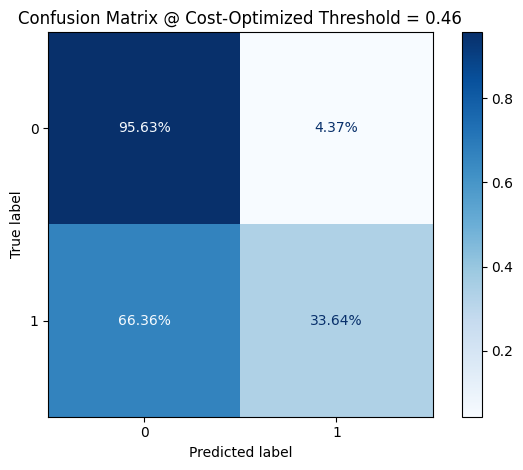


📉 Business Cost Evaluation for Logit-Baseline:
🔹 Best Threshold (Cost-Optimized): 0.455
🔹 Expected Loss: 0.510  [FN cost = 4, FP cost = 1]

📊 Logit-Baseline: Train RMSE = 0.4459, Valid RMSE = 0.4459
✅ Finished: Logit-Baseline



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['election_keyword_count',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(estimator=LogisticRegression(C=0.1,
                                                                     max_iter=1000,
                                                                     penalty='l1',
                                                                     random_state=42,
                                                                     solver='liblinear')))])

In [16]:
lib.helper_fun.run_model_with_gridsearch('Logit-Baseline', pipe_logit, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    baseline_features, categorical_features
)

🔍 Running model: Logit-non_llm


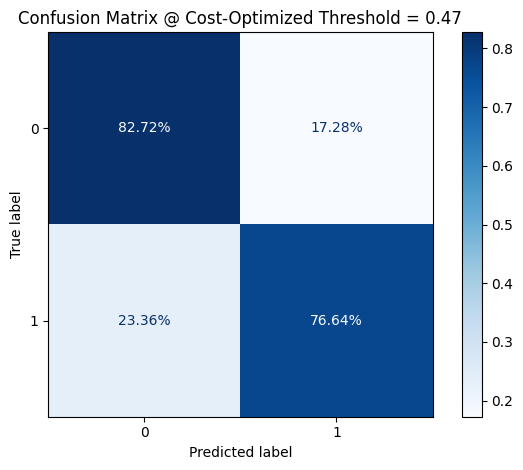


📉 Business Cost Evaluation for Logit-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.465
🔹 Expected Loss: 0.309  [FN cost = 4, FP cost = 1]

📊 Logit-non_llm: Train RMSE = 0.3460, Valid RMSE = 0.3628
✅ Finished: Logit-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'mentions_election_keywords',
                                                   'election_certainty',
                                                   'no_title']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(estimator=LogisticRegression(C=0.1,
                                                                     max_iter=1000,
                                                                     penalty='l1',
                                                                     random_state=42,
                                                                     solver='liblinear')))])

In [17]:
lib.helper_fun.run_model_with_gridsearch('Logit-non_llm', pipe_logit1, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: Logit-llm


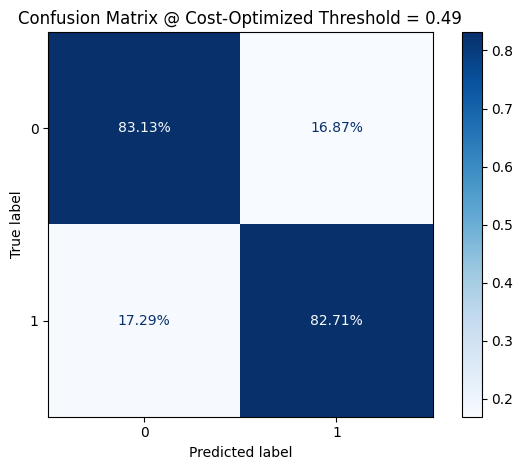


📉 Business Cost Evaluation for Logit-llm:
🔹 Best Threshold (Cost-Optimized): 0.485
🔹 Expected Loss: 0.262  [FN cost = 4, FP cost = 1]

📊 Logit-llm: Train RMSE = 0.3310, Valid RMSE = 0.3430
✅ Finished: Logit-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'has_entities',
                                                   'has_relationships',
                                                   'has_people', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(estimator=LogisticRegression(max_iter=1000,
                                                                     penalty='l1',
                                                                     random_state=42,
                                                                     solver='liblinear')))])

In [18]:
lib.helper_fun.run_model_with_gridsearch('Logit-llm', pipe_logit2, logit_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

In [36]:
collector.get_table()

,Train AUC,Test AUC,Expected Loss
Logit-Baseline,0.446,0.446,0.510
Logit-non_llm,0.346,0.363,0.309
Logit-llm,0.331,0.343,0.262
rf-non_llm,0.254,0.309,0.276
rf-llm,0.221,0.298,0.263
xgb_smote-non_llm,0.239,0.288,0.273
xgb_smote-llm,0.081,0.272,0.216
xgb_new_smote-non_llm,0.222,0.279,0.260
xgb_new_smote-llm,0.195,0.273,0.245
xgb_pca-non_llm,0.277,0.336,0.285


## rf

🔍 Running model: rf-non_llm


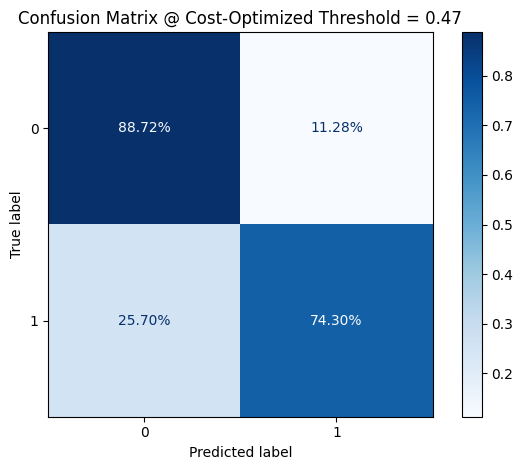


📉 Business Cost Evaluation for rf-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.465
🔹 Expected Loss: 0.276  [FN cost = 4, FP cost = 1]

📊 rf-non_llm: Train RMSE = 0.2542, Valid RMSE = 0.3090
✅ Finished: rf-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                                        estimator=RandomForestClassifier(criterion='entropy',
                                                                         max_depth=10,
                                                                         min_samples_split=5,
                                                                         n_estimators=200,
                                                                         random_state=42)))])

In [21]:
lib.helper_fun.run_model_with_gridsearch('rf-non_llm', pipe_rf, rf_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: rf-llm


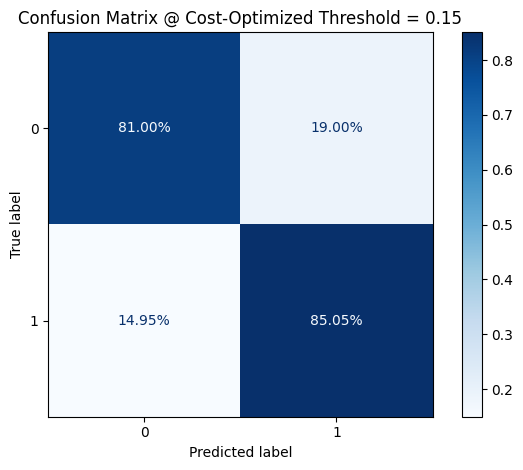


📉 Business Cost Evaluation for rf-llm:
🔹 Best Threshold (Cost-Optimized): 0.149
🔹 Expected Loss: 0.263  [FN cost = 4, FP cost = 1]

📊 rf-llm: Train RMSE = 0.2212, Valid RMSE = 0.2984
✅ Finished: rf-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                                        estimator=RandomForestClassifier(criterion='entropy',
                                                                         max_depth=10,
                                                                         min_samples_split=5,
                                                                         n_estimators=200,
                                                                         random_state=42)))])

In [22]:
lib.helper_fun.run_model_with_gridsearch('rf-llm', pipe_rf2, rf_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

## xgb

🔍 Running model: xgb_smote-non_llm


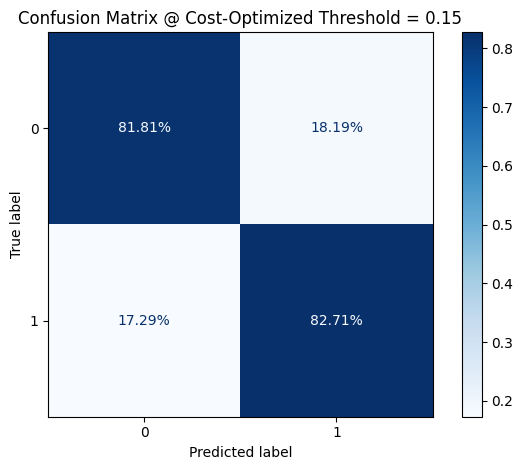


📉 Business Cost Evaluation for xgb_smote-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.149
🔹 Expected Loss: 0.273  [FN cost = 4, FP cost = 1]

📊 xgb_smote-non_llm: Train RMSE = 0.2395, Valid RMSE = 0.2880
✅ Finished: xgb_smote-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [23]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-non_llm', pipe_xgb_smote, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_smote-llm


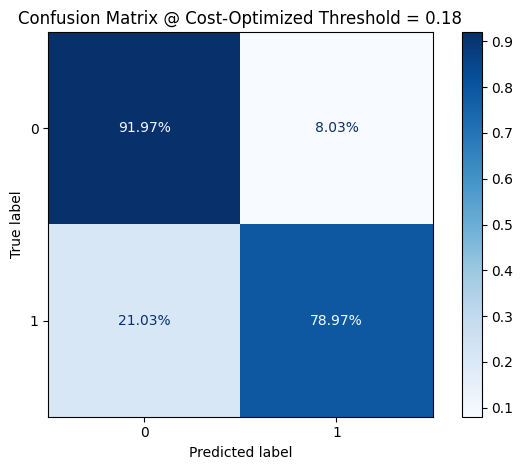


📉 Business Cost Evaluation for xgb_smote-llm:
🔹 Best Threshold (Cost-Optimized): 0.178
🔹 Expected Loss: 0.216  [FN cost = 4, FP cost = 1]

📊 xgb_smote-llm: Train RMSE = 0.0807, Valid RMSE = 0.2720
✅ Finished: xgb_smote-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=15,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [24]:
lib.helper_fun.run_model_with_gridsearch('xgb_smote-llm', pipe_xgb_smote2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

🔍 Running model: xgb_new_smote-non_llm


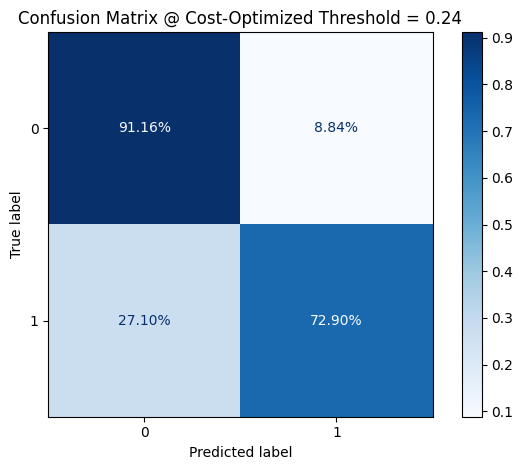


📉 Business Cost Evaluation for xgb_new_smote-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.238
🔹 Expected Loss: 0.266  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-non_llm: Train RMSE = 0.2307, Valid RMSE = 0.2781
✅ Finished: xgb_new_smote-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [16]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-non_llm', pipe_xgb_new_smote, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

loss = fp-cost = 1 
fn_cost = 3 

i tried with fn = 4 but that gave us more fp and i made the final decision based on theexpected loss - which was 

0.2170
vs 
0.2598
i chose the more aggresive one because the 0.04 difference results in 51 units of losss 
0.043 × 1,198 ≈ **51.5 units of cost**


▶ Choose the FN = 4 model (Threshold 0.14) if:
	•	You’re in a high-stakes environment (e.g. political campaigns, public health, fraud, etc.)
	•	Missing a true positive is significantly worse than alerting a few false ones
	•	You want to err on the side of over-detection

In [26]:
# valid_probs = best_models['xgb_new_smote-non_llm'].predict_proba(X_valid)[:, 1]

# threshold, expected_loss = lib.helper_fun.compute_expected_loss(y_valid, valid_probs)

# y_pred_cost = (valid_probs >= threshold).astype(int)

# cm = confusion_matrix(y_valid, y_pred_cost, normalize='true')
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
# disp.plot(cmap="Blues", values_format=".2%")
# plt.title(f"Confusion Matrix @ Cost-Optimized Threshold = {threshold:.2f}")
# plt.grid(False)
# plt.tight_layout()
# plt.show()


In [27]:
# valid_probs = best_models['xgb_new_smote-non_llm'].predict_proba(X_valid)[:, 1]

# threshold, expected_loss = lib.helper_fun.compute_expected_loss(y_valid, valid_probs)

# y_pred_cost = (valid_probs >= threshold).astype(int)

# cm = confusion_matrix(y_valid, y_pred_cost)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
# disp.plot(cmap="Blues")
# plt.title(f"Confusion Matrix @ Cost-Optimized Threshold = {threshold:.2f}")
# plt.grid(False)
# plt.tight_layout()
# plt.show()

🔍 Running model: xgb_new_smote-llm


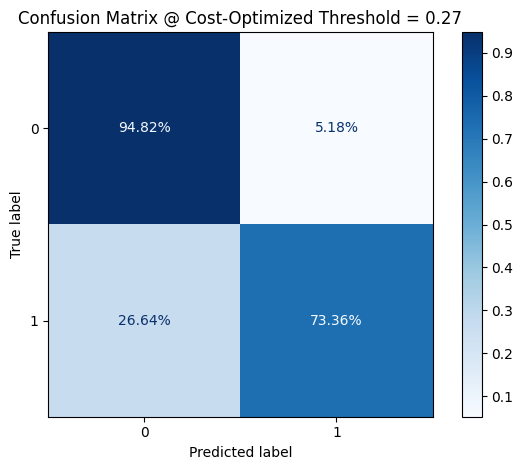


📉 Business Cost Evaluation for xgb_new_smote-llm:
🔹 Best Threshold (Cost-Optimized): 0.267
🔹 Expected Loss: 0.233  [FN cost = 4, FP cost = 1]

📊 xgb_new_smote-llm: Train RMSE = 0.1175, Valid RMSE = 0.2700
✅ Finished: xgb_new_smote-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=15,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [17]:
lib.helper_fun.run_model_with_gridsearch('xgb_new_smote-llm', pipe_xgb_new_smote2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

🔍 Running model: xgb_pca-non_llm


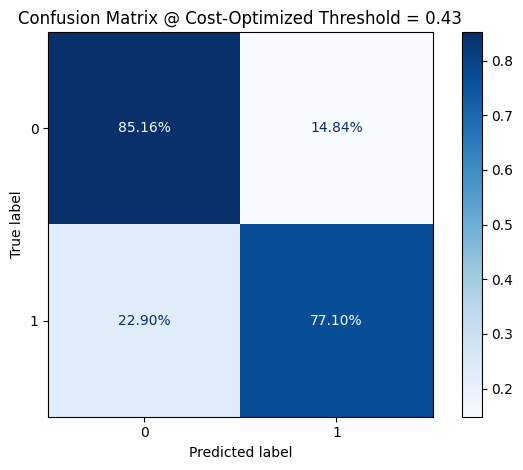


📉 Business Cost Evaluation for xgb_pca-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.426
🔹 Expected Loss: 0.285  [FN cost = 4, FP cost = 1]

📊 xgb_pca-non_llm: Train RMSE = 0.2771, Valid RMSE = 0.3356
✅ Finished: xgb_pca-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [29]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-non_llm', pipe_xgb_smote_pca, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_pca-llm


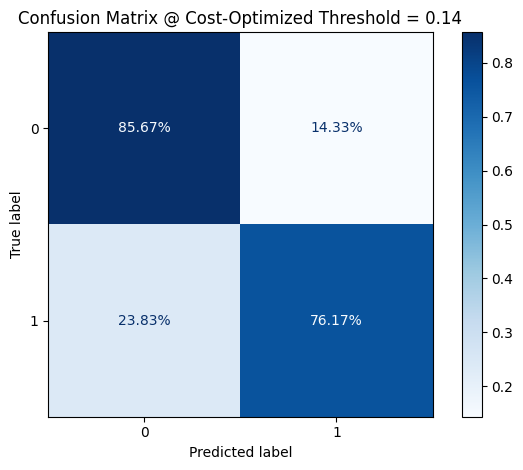


📉 Business Cost Evaluation for xgb_pca-llm:
🔹 Best Threshold (Cost-Optimized): 0.139
🔹 Expected Loss: 0.288  [FN cost = 4, FP cost = 1]

📊 xgb_pca-llm: Train RMSE = 0.0713, Valid RMSE = 0.3202
✅ Finished: xgb_pca-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=10,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [30]:
lib.helper_fun.run_model_with_gridsearch('xgb_pca-llm', pipe_xgb_smote_pca2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

🔍 Running model: xgb_select-non_llm


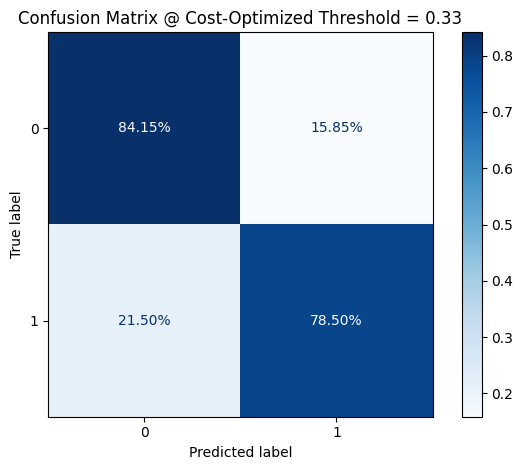


📉 Business Cost Evaluation for xgb_select-non_llm:
🔹 Best Threshold (Cost-Optimized): 0.327
🔹 Expected Loss: 0.284  [FN cost = 4, FP cost = 1]

📊 xgb_select-non_llm: Train RMSE = 0.2760, Valid RMSE = 0.3158
✅ Finished: xgb_select-non_llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [32]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-non_llm', pipe_xgb_calibrated_select_features, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: xgb_select-llm


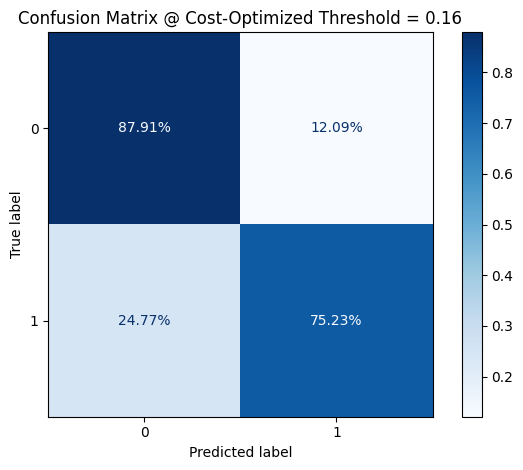


📉 Business Cost Evaluation for xgb_select-llm:
🔹 Best Threshold (Cost-Optimized): 0.158
🔹 Expected Loss: 0.276  [FN cost = 4, FP cost = 1]

📊 xgb_select-llm: Train RMSE = 0.1062, Valid RMSE = 0.3060
✅ Finished: xgb_select-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=15,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=100,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

In [33]:
lib.helper_fun.run_model_with_gridsearch('xgb_select-llm', pipe_xgb_calibrated_select_features2, xgb_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

## catboost 

In [13]:
lib.helper_fun.run_model_with_gridsearch('cat-non_llm', pipe_cat, catboost_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    non_llm_features, categorical_features
)

🔍 Running model: cat-non_llm


KeyboardInterrupt: 

🔍 Running model: cat-llm


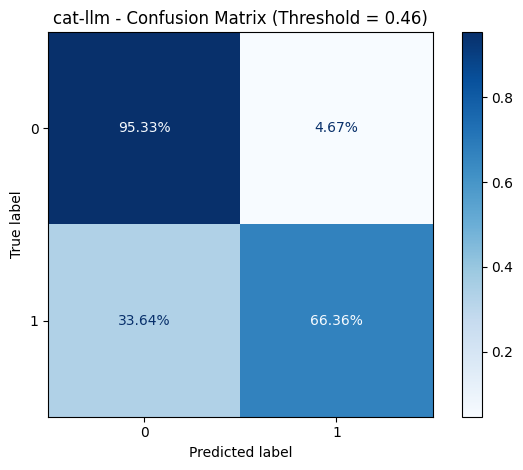

📊 cat-llm: Train RMSE = 0.9818, Valid RMSE = 0.9218
✅ Finished: cat-llm



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                   'has_relationships',
                                                   'has_people', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE(random_state=42)),
                ('calibrated_model',
                 CalibratedClassifierCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                                        estimator=<catboost.core.CatBoostClassifier object at 0x154aac230>))])

In [56]:
lib.helper_fun.run_model_with_gridsearch('cat-llm', pipe_cat2, catboost_param_grid, 
    X_train, y_train, X_valid, y_valid,
    results, best_models, lib.helper_fun.matrix, collector,
    all_features_with_llm, categorical_features
)

# results 

In [14]:
collector.get_table()

# examing the fps for the best perfoming model xgb_smote 

In [35]:
best_models['xgb_smote-non_llm']

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=3,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

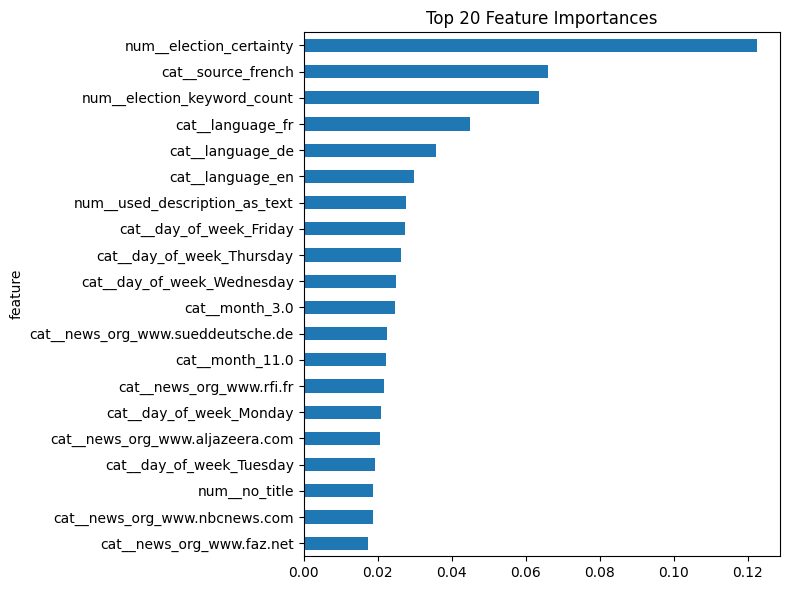

In [43]:


# Get trained model (assumes last trained model is best_model)
# Get the final model from the pipeline
xgb_model = best_models['xgb_smote-non_llm']

# Extract the fitted estimator from CalibratedClassifierCV (first fold)
final_estimator = xgb_model.named_steps['calibrated_model'].calibrated_classifiers_[0].estimator

# Get feature names from preprocessor
encoded_feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_estimator.feature_importances_

# Create and plot
feat_imp_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp_df.head(20).plot.barh(x='feature', y='importance', figsize=(8, 6), legend=False)
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
xgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['used_description_as_text',
                                                   'is_weekend',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'contains_question',
                                                   'quote_count',
                                                   'contains_number',
                                                   'capital...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=200,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...)))])

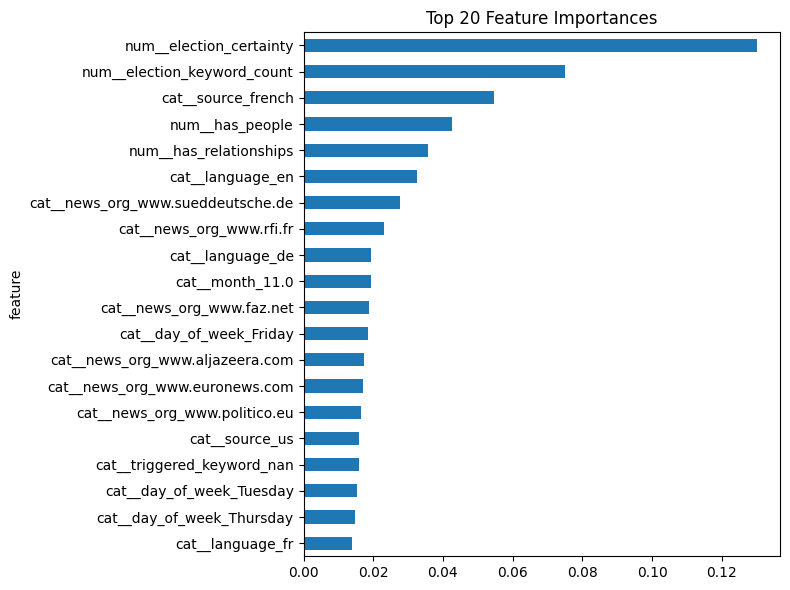

In [42]:

# Get trained model (assumes last trained model is best_model)
# Get the final model from the pipeline
xgb_model = best_models['xgb_smote-llm']

# Extract the fitted estimator from CalibratedClassifierCV (first fold)
final_estimator = xgb_model.named_steps['calibrated_model'].calibrated_classifiers_[0].estimator

# Get feature names from preprocessor
encoded_feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_estimator.feature_importances_

# Create and plot
feat_imp_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp_df.head(20).plot.barh(x='feature', y='importance', figsize=(8, 6), legend=False)
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [46]:
# Apply cost-optimized threshold
y_pred_cost = (valid_probs >= threshold).astype(int)

# Get mask for false negatives
false_neg_mask = (y_valid == 1) & (y_pred_cost == 0)

# Extract those rows from your original validation set
false_negatives = X_valid[false_neg_mask].copy()
false_negatives["true_label"] = y_valid[false_neg_mask]
false_negatives["pred_prob"] = valid_probs[false_neg_mask]

In [51]:
false_negatives["source"].value_counts().head(10)
#false_negatives["language"].value_counts()
#false_negatives["used_description_as_text"].mean()
#false_negatives["mentions_election_keywords"].mean()
#false_negatives[["has_people", "has_relationships", "has_organizations"]].mean()

source
french    30
german    26
us        13
Name: count, dtype: int64

In [52]:
# True positives
true_pos_mask = (y_valid == 1) & (y_pred_cost == 1)
true_positives = X_valid[true_pos_mask]

# Compare means
comparison = pd.DataFrame({
    "false_neg": false_negatives.mean(),
    "true_pos": true_positives.mean()
})
comparison["diff"] = comparison["false_neg"] - comparison["true_pos"]
comparison.sort_values("diff", ascending=False).head(10)

TypeError: can only concatenate str (not "int") to str

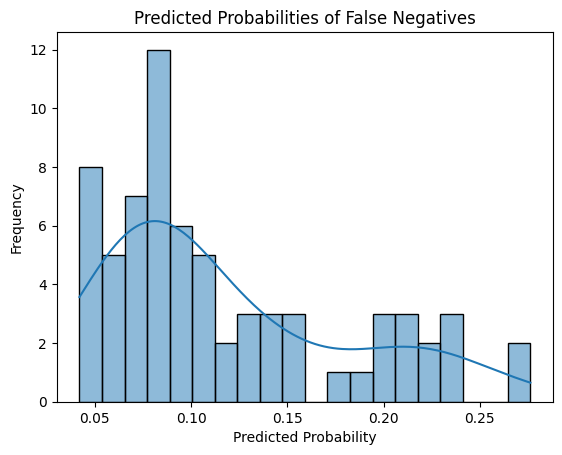

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(false_negatives["pred_prob"], bins=20, kde=True)
plt.title("Predicted Probabilities of False Negatives")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

# trial run on logit 

In [167]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), [f for f in baseline_features if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in baseline_features if f in categorical_features])
])

pipe_logit_baseline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_logit_baseline.fit(X_train[baseline_features], y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['election_keyword_count',
                                                   'days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('smote', SMOTE()),
                ('clf', LogisticRegression(max_iter=1000))])

In [103]:
y_train_probs = pipe_logit_baseline.predict_proba(X_train[baseline_features])[:, 1]
y_valid_probs = pipe_logit_baseline.predict_proba(X_valid[baseline_features])[:, 1]

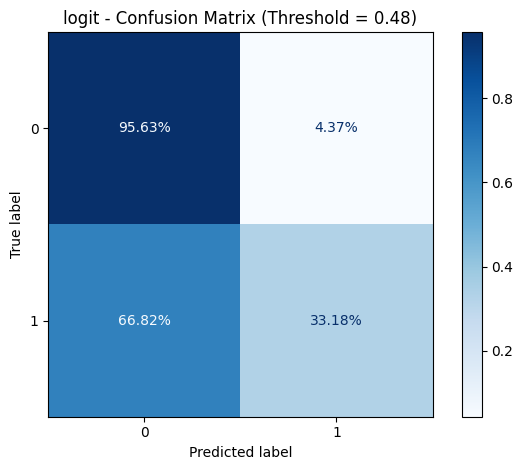

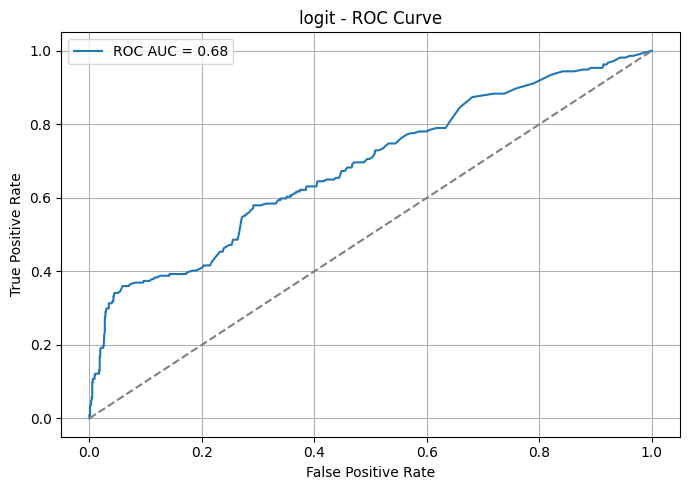

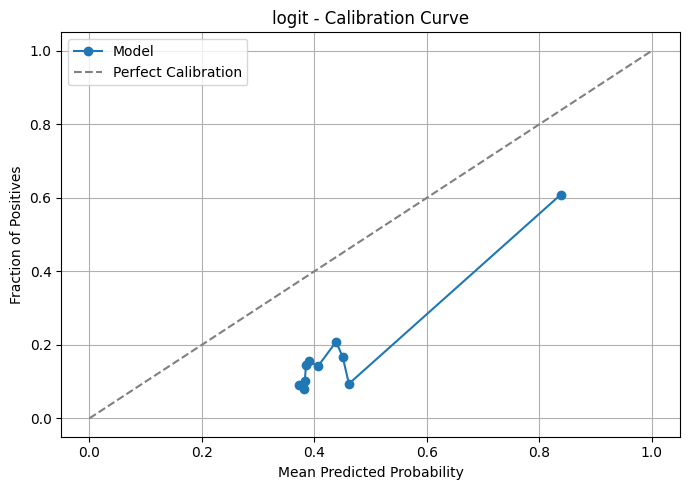

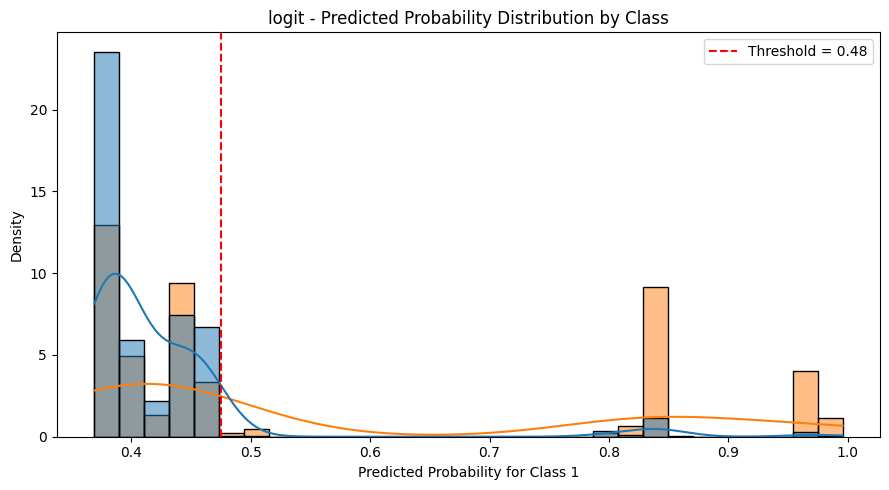


📊 Classification Report (Threshold = 0.48):
              precision    recall  f1-score   support

           0      0.868     0.956     0.910       984
           1      0.623     0.332     0.433       214

    accuracy                          0.845      1198
   macro avg      0.745     0.644     0.671      1198
weighted avg      0.824     0.845     0.825      1198


📈 Train RMSE: 0.4471
📈 Test  RMSE: 0.4466


{'Model': 'logit',
 'Threshold': 0.475,
 'Train RMSE': 0.447,
 'Test RMSE': 0.447,
 'AUC': 0.684,
 'F1': 0.433}

In [104]:

lib.helper_fun.diagnostics(y_train, y_train_probs, y_valid, y_valid_probs, model_name="logit")

In [ ]:
results.add_model("logit")

In [57]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor_all_llm = ColumnTransformer([
    ('num', StandardScaler(), [
        f for f in all_features_with_llm
        if f not in categorical_features + binary_flags + drop_columns
    ]),
    ('bin', 'passthrough', [f for f in all_features_with_llm if f in binary_flags]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in all_features_with_llm if f in categorical_features])
])

pipe_xgb_all_llm = ImbPipeline([
    ('preprocessor', preprocessor_all_llm),
    ('smote', SMOTE()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

param_grid_xgb = {
    'clf__max_depth': [3, 5],
    'clf__n_estimators': [50, 100],
    'clf__learning_rate': [0.05, 0.1]
}

grid_xgb_all_llm = GridSearchCV(pipe_xgb_all_llm, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_xgb_all_llm.fit(X_train[all_features_with_llm], y_train)

/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['days_until_us_election',
                                                                          'days_until_french_election',
                                                                          'days_until_german_election',
                                                                          'word_count',
                                                                          'sentence_count',
                                                                          'avg_sentence_length',
                                                                          'noun_count',
                                                                          'verb_count',
                                                                          'quote_count',
                                                                          'capital_ratio',
                                                                          'election_keyword_count',
                                                                          'election_certain...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'clf__learning_rate': [0.05, 0.1],
                         'clf__max_depth': [3, 5],
                         'clf__n_estimators': [50, 100]},
             scoring='f1')

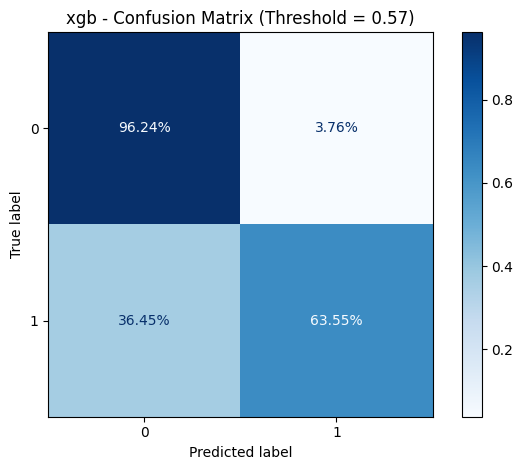

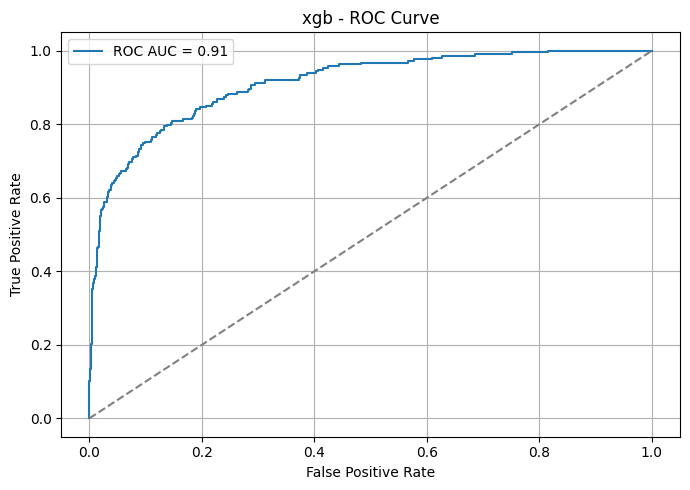

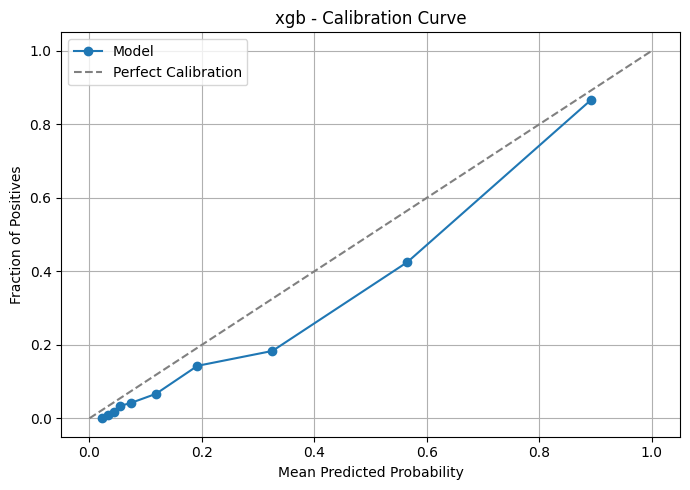

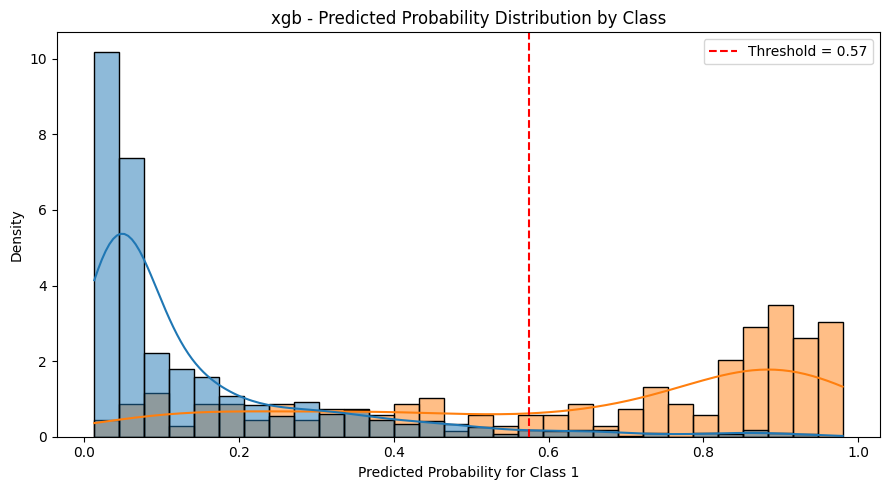


📊 Classification Report (Threshold = 0.57):
              precision    recall  f1-score   support

           0      0.924     0.962     0.943       984
           1      0.786     0.636     0.703       214

    accuracy                          0.904      1198
   macro avg      0.855     0.799     0.823      1198
weighted avg      0.899     0.904     0.900      1198


📈 Train RMSE: 0.2477
📈 Test  RMSE: 0.2849


{'Model': 'xgb',
 'Threshold': 0.574,
 'Train RMSE': 0.248,
 'Test RMSE': 0.285,
 'AUC': 0.911,
 'F1': 0.703}

In [59]:
y_train_probs = grid_xgb_all_llm.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = grid_xgb_all_llm.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.diagnostics(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb")

In [60]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Compute class imbalance ratio
neg, pos = y_train.value_counts()
imbalance_ratio = neg / pos

# Create pipeline
pipe_xgb_weighted = ImbPipeline([
    ('preprocessor', preprocessor_all_llm),
    ('smote', SMOTE()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Grid search with class weight tuning
param_grid_weighted = {
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1],
    'clf__n_estimators': [100],
    'clf__scale_pos_weight': [1, imbalance_ratio, imbalance_ratio * 1.5]
}

grid_xgb_weighted = GridSearchCV(
    pipe_xgb_weighted,
    param_grid_weighted,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb_weighted.fit(X_train[all_features_with_llm], y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['days_until_us_election',
                                                                          'days_until_french_election',
                                                                          'days_until_german_election',
                                                                          'word_count',
                                                                          'sentence_count',
                                                                          'avg_sentence_length',
                                                                          'noun_count',
                                                                          'verb_count',
                                                                          'quote_count',
                                                                          'capital_ratio',
                                                                          'election_keyword_count',
                                                                          'election_certain...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'clf__learning_rate': [0.05, 0.1],
                         'clf__max_depth': [3, 5], 'clf__n_estimators': [100],
                         'clf__scale_pos_weight': [1, 4.588098016336056,
                                                   6.882147024504084]},
             scoring='f1', verbose=1)

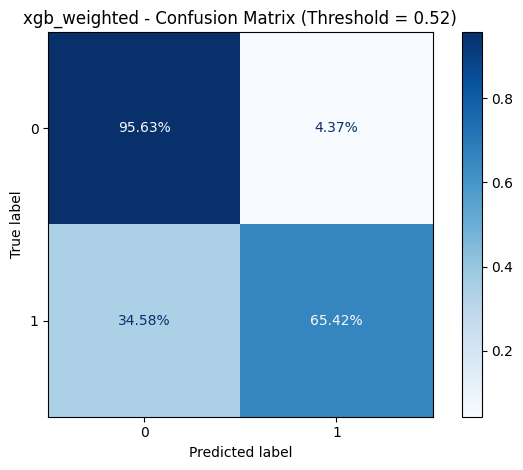

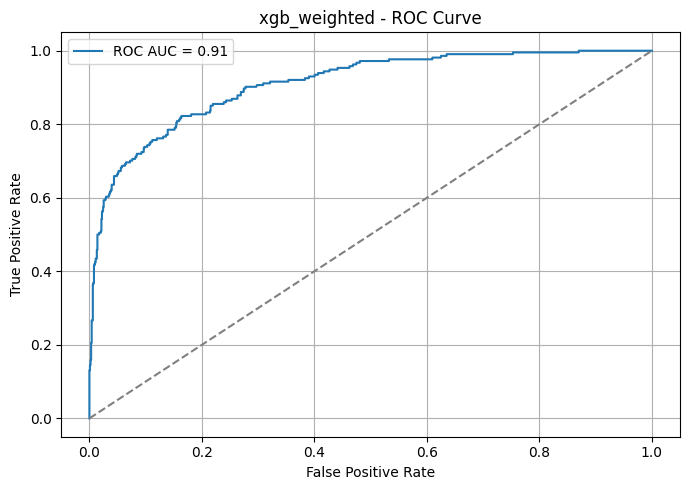

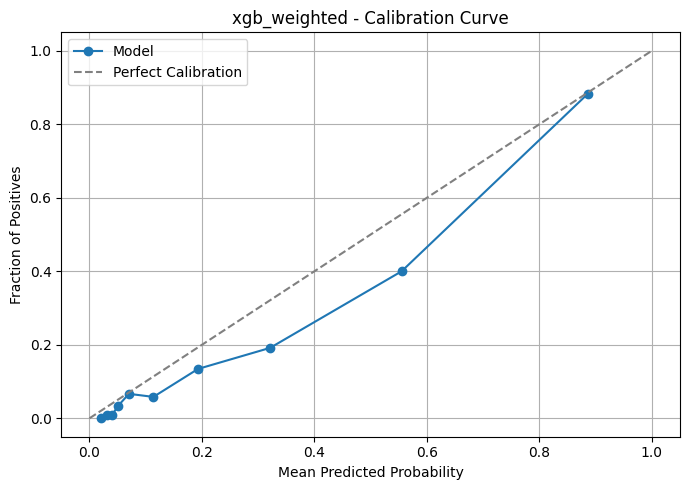

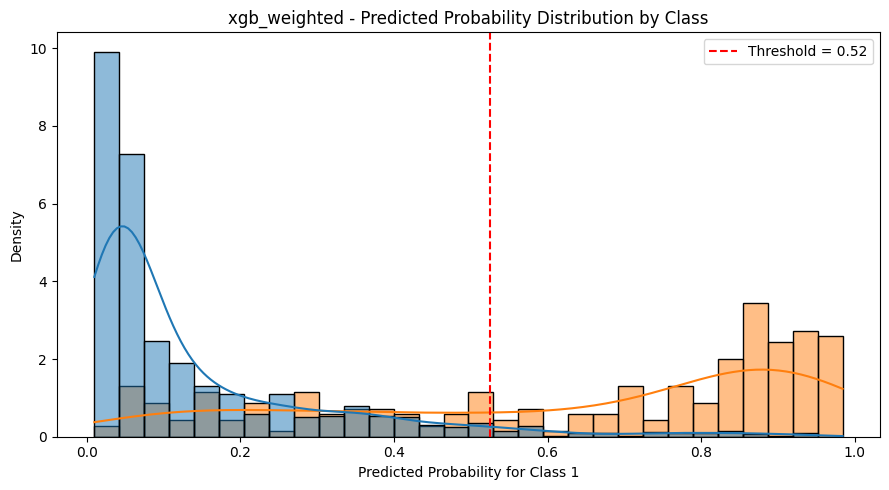


📊 Classification Report (Threshold = 0.52):
              precision    recall  f1-score   support

           0      0.927     0.956     0.941       984
           1      0.765     0.654     0.705       214

    accuracy                          0.902      1198
   macro avg      0.846     0.805     0.823      1198
weighted avg      0.898     0.902     0.899      1198


📈 Train RMSE: 0.2472
📈 Test  RMSE: 0.2853


{'Model': 'xgb_weighted',
 'Threshold': 0.525,
 'Train RMSE': 0.247,
 'Test RMSE': 0.285,
 'AUC': 0.909,
 'F1': 0.705}

In [61]:
y_train_probs = grid_xgb_weighted.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = grid_xgb_weighted.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.diagnostics(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_weighted")

In [63]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bbc_model = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_estimators=10,
    n_jobs=-1
)

pipe_bbc = ImbPipeline([
    ('preprocessor', preprocessor_all_llm),
    ('smote', SMOTE()),
    ('clf', bbc_model)
])

pipe_bbc.fit(X_train[all_features_with_llm], y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['days_until_us_election',
                                                   'days_until_french_election',
                                                   'days_until_german_election',
                                                   'word_count',
                                                   'sentence_count',
                                                   'avg_sentence_length',
                                                   'noun_count', 'verb_count',
                                                   'quote_count',
                                                   'capital_ratio',
                                                   'election_keyword_count',
                                                   'election_certainty',
                                                   'L_n_total_entities',
                                                   'L_...
                                                   'contains_question',
                                                   'contains_number',
                                                   'mentions_social_media',
                                                   'mentions_election_keywords',
                                                   'no_title']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['language', 'source',
                                                   'news_org', 'day_of_week',
                                                   'month',
                                                   'triggered_keyword'])])),
                ('smote', SMOTE()),
                ('clf',
                 BalancedBaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                                           n_jobs=-1, random_state=42))])

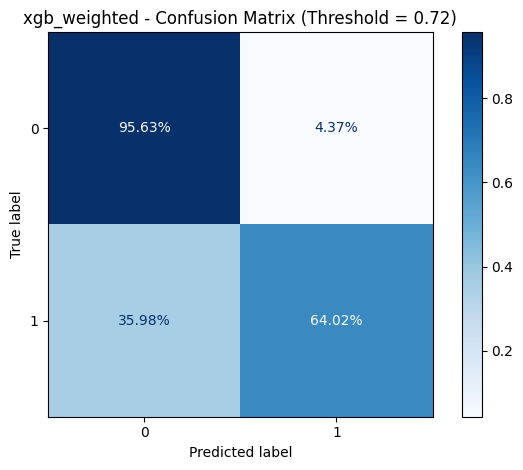

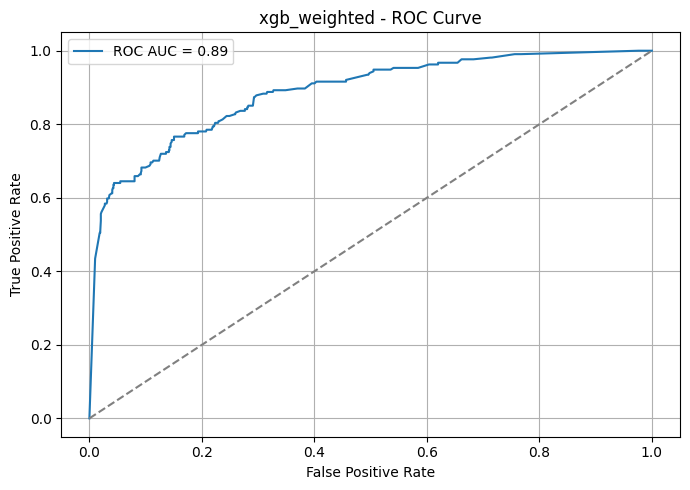

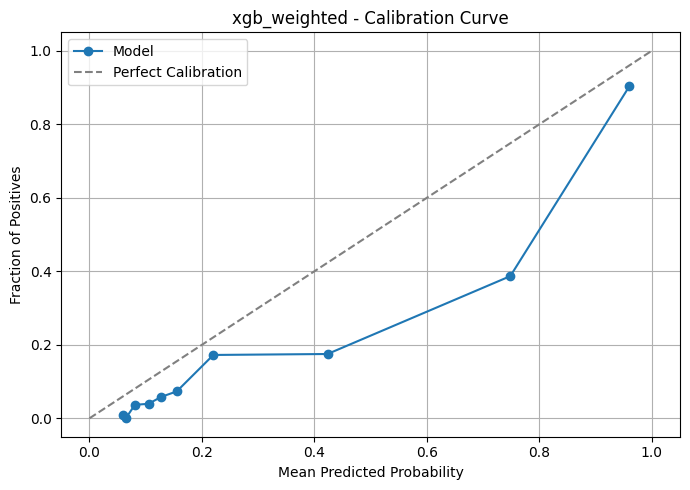

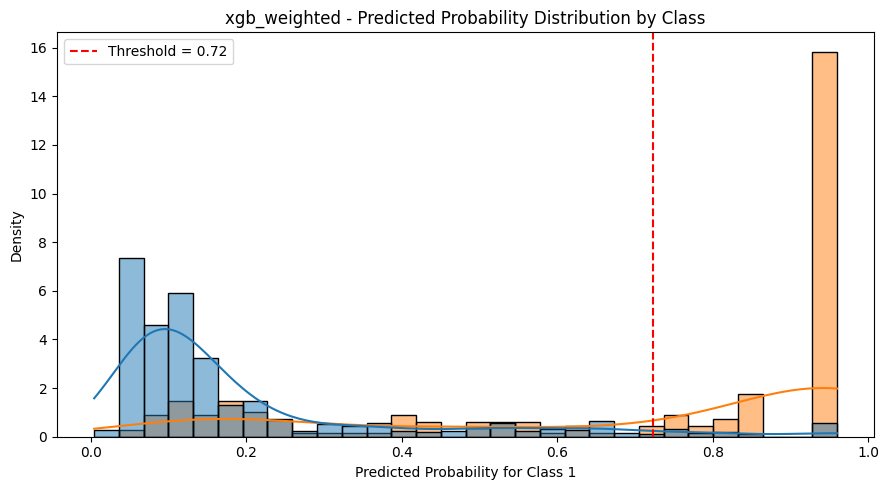


📊 Classification Report (Threshold = 0.72):
              precision    recall  f1-score   support

           0      0.924     0.956     0.940       984
           1      0.761     0.640     0.695       214

    accuracy                          0.900      1198
   macro avg      0.843     0.798     0.818      1198
weighted avg      0.895     0.900     0.896      1198


📈 Train RMSE: 0.3006
📈 Test  RMSE: 0.3242


{'Model': 'xgb_weighted',
 'Threshold': 0.723,
 'Train RMSE': 0.301,
 'Test RMSE': 0.324,
 'AUC': 0.886,
 'F1': 0.695}

In [64]:
y_train_probs = pipe_bbc.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = pipe_bbc.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.diagnostics(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_weighted")

In [82]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from xgboost import XGBClassifier

# Update your preprocessor
preprocessor_llm = ColumnTransformer([
    ('num', StandardScaler(), [f for f in all_features_with_llm if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in all_features_with_llm if f in categorical_features])
])

# Update your preprocessor
preprocessor_no_llm = ColumnTransformer([
    ('num', StandardScaler(), [f for f in non_llm_features if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in non_llm_features if f in categorical_features])
])



# 2. XGBoost with ADASYN
pipe_xgb_adasyn = ImbPipeline([
    ('preprocessor', preprocessor_llm),
    ('adasyn', ADASYN()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 3. XGBoost with PCA
pipe_xgb_pca = ImbPipeline([
    ('preprocessor', preprocessor_llm),
    ('smote', SMOTE()),
    ('pca', PCA(n_components=5)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 4. Logistic Regression + feature selection
pipe_logit_select = ImbPipeline([
    ('preprocessor', preprocessor_llm),
    ('smote', SMOTE()),
    ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))),
    ('clf', LogisticRegression(max_iter=1000))
])


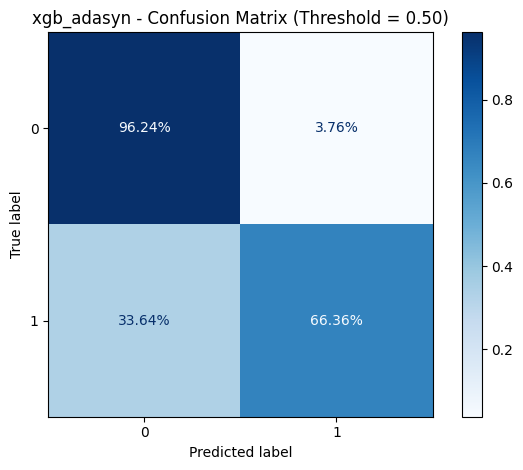

In [68]:
pipe_xgb_adasyn.fit(X_train[all_features_with_llm], y_train)
y_train_probs = pipe_xgb_adasyn.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = pipe_xgb_adasyn.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_adasyn")

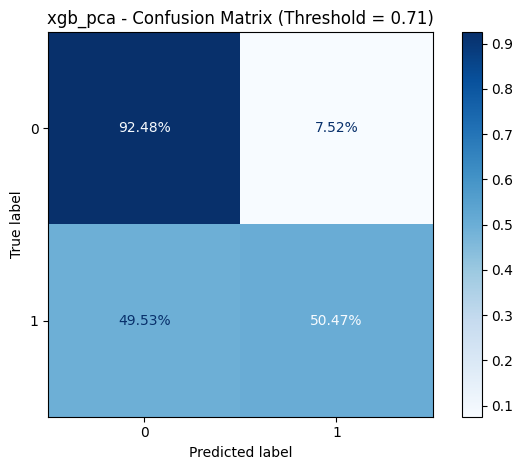

In [69]:
pipe_xgb_pca.fit(X_train[all_features_with_llm], y_train)
y_train_probs = pipe_xgb_pca.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = pipe_xgb_pca.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_pca")

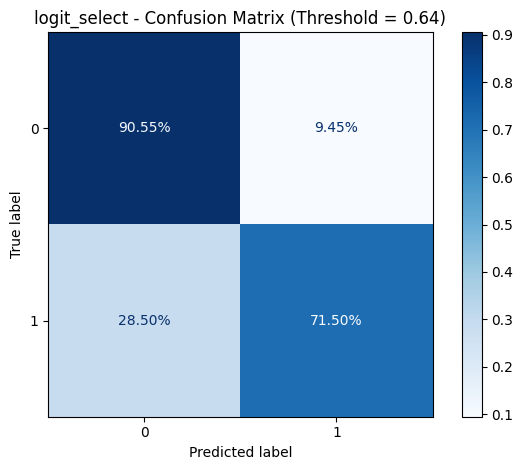

In [ ]:

pipe_logit_select.fit(X_train[all_features_with_llm], y_train)
y_train_probs = pipe_logit_select.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = pipe_logit_select.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="logit_select")

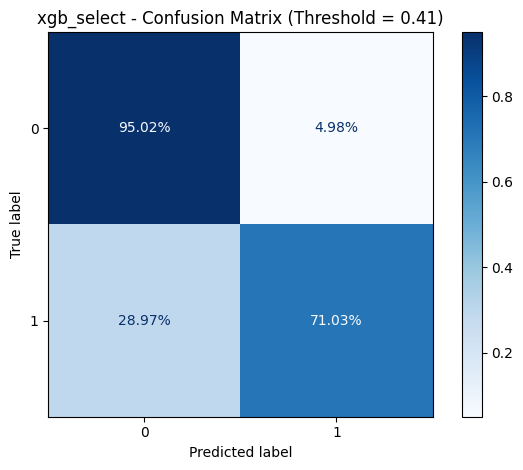

In [84]:
# Define pipeline: XGB with feature selection
pipe_xgb_select = ImbPipeline([
    ('preprocessor', preprocessor_llm),
    ('smote', SMOTE()),
    ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

pipe_xgb_select.fit(X_train[all_features_with_llm], y_train)
y_train_probs = pipe_xgb_select.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = pipe_xgb_select.predict_proba(X_valid[all_features_with_llm])[:, 1]
lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_select")

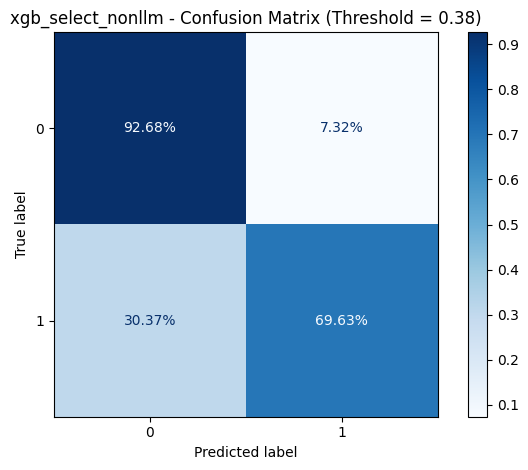

In [90]:
# Define pipeline: XGB with feature selection
pipe_xgb_select2 = ImbPipeline([
    ('preprocessor', preprocessor_no_llm),
    ('smote', SMOTE()),
    ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

pipe_xgb_select2.fit(X_train[non_llm_features], y_train)
y_train_probs = pipe_xgb_select2.predict_proba(X_train[non_llm_features])[:, 1]
y_valid_probs = pipe_xgb_select2.predict_proba(X_valid[non_llm_features])[:, 1]
lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_select_nonllm")

/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^

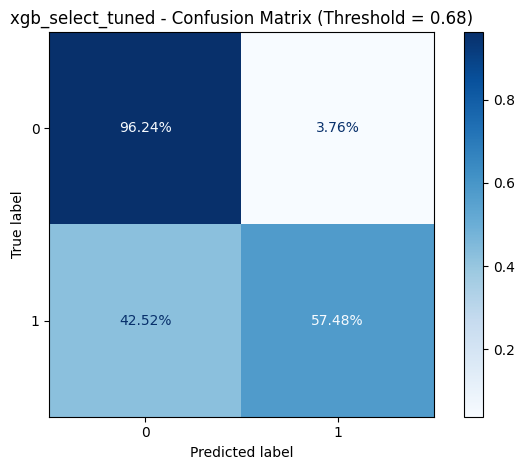

In [99]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Fix seed
RANDOM_STATE = 42
roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Hyperparameter grid
param_grid_expanded = {
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__n_estimators': [100, 200],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0]
}


# Pipeline
pipeline_xgb_select = ImbPipeline([
    ('preprocessor', preprocessor_llm),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    #('selector', SelectFromModel(XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='auc'))),
    ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))),
    ('clf', XGBClassifier(random_state=RANDOM_STATE, eval_metric='auc'))
])


# pipe_xgb_select = ImbPipeline([
#     ('preprocessor', preprocessor_llm),
#     ('smote', SMOTE()),
#     ('selector', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))),
#     ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
# ])




# GridSearch
grid_search_xgb_select = GridSearchCV(
    pipeline_xgb_select,
    param_grid=param_grid_expanded,
    scoring=roc_auc_scorer,
    cv=5,
    n_jobs=-1,
    verbose=0
)

# Fit
grid_search_xgb_select.fit(X_train[all_features_with_llm], y_train)

# Predict probs
y_train_probs = grid_search_xgb_select.predict_proba(X_train[all_features_with_llm])[:, 1]
y_valid_probs = grid_search_xgb_select.predict_proba(X_valid[all_features_with_llm])[:, 1]

lib.helper_fun.matrix(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_select_tuned")

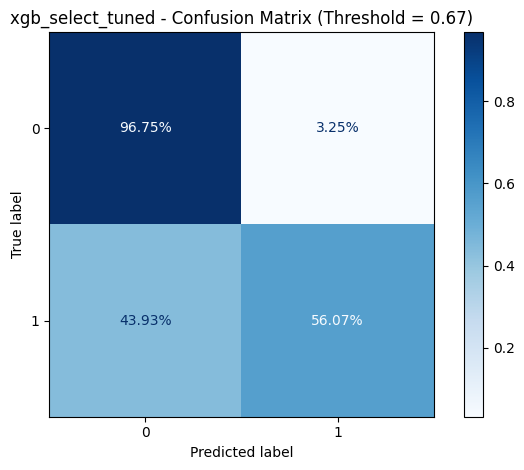

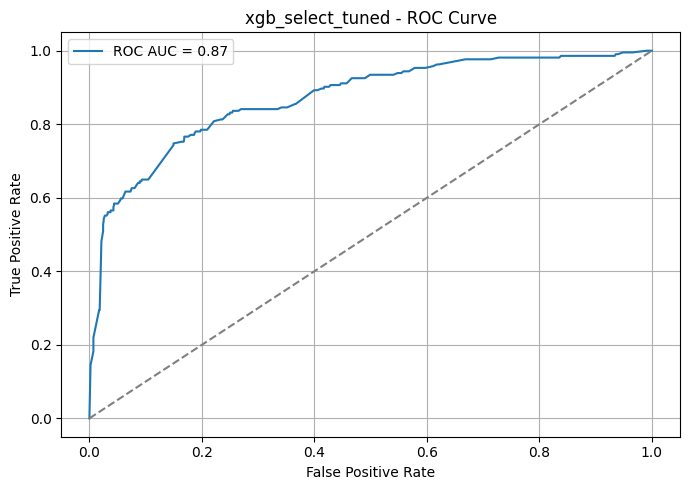

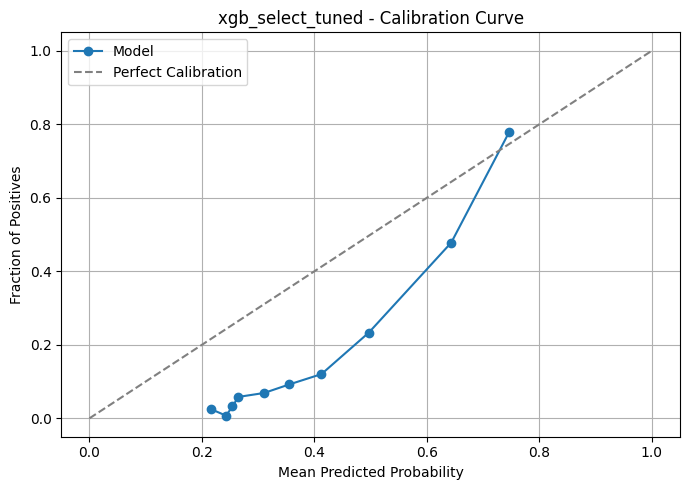

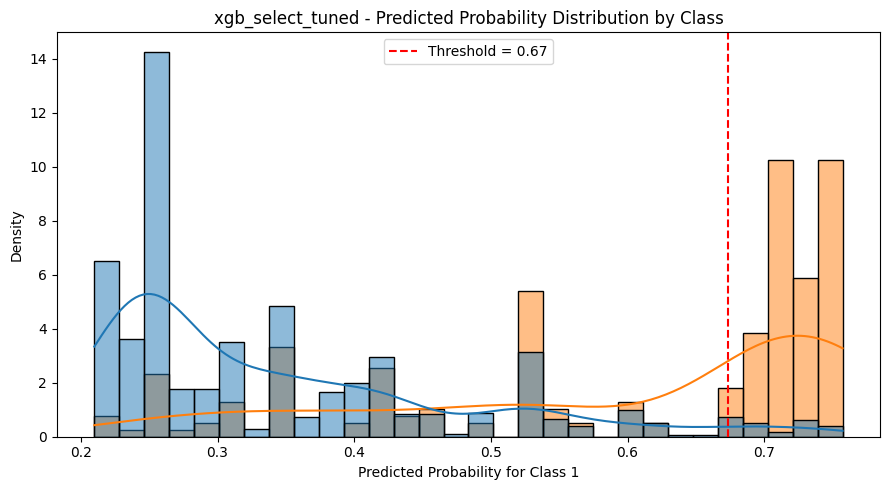


📊 Classification Report (Threshold = 0.67):
              precision    recall  f1-score   support

           0      0.910     0.967     0.938       984
           1      0.789     0.561     0.656       214

    accuracy                          0.895      1198
   macro avg      0.850     0.764     0.797      1198
weighted avg      0.889     0.895     0.888      1198


📈 Train RMSE: 0.3729
📈 Test  RMSE: 0.3803


{'Model': 'xgb_select_tuned',
 'Threshold': 0.673,
 'Train RMSE': 0.373,
 'Test RMSE': 0.380,
 'AUC': 0.871,
 'F1': 0.656}

In [95]:

lib.helper_fun.diagnostics(y_train, y_train_probs, y_valid, y_valid_probs, model_name="xgb_select_tuned")

# other 

In [ ]:
# Top 2 predictors
preprocessor_top2 = ColumnTransformer([
    ('num', StandardScaler(), [f for f in top2_features if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in top2_features if f in categorical_features])
])

# All predictors (no LLM)
preprocessor_all = ColumnTransformer([
    ('num', StandardScaler(), [f for f in all_features if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in all_features if f in categorical_features])
])

# All predictors + LLM
preprocessor_all_llm = ColumnTransformer([
    ('num', StandardScaler(), [f for f in all_features_with_llm if f not in categorical_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in all_features_with_llm if f in categorical_features])
])

In [ ]:
# 1. XGBoost with top 2 predictors
pipe_xgb_top2 = ImbPipeline([
    ('preprocessor', preprocessor_top2),
    ('smote', SMOTE()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 2. XGBoost with all predictors (no LLM)
pipe_xgb_all = ImbPipeline([
    ('preprocessor', preprocessor_all),
    ('smote', SMOTE()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 3. XGBoost with all predictors + LLM
pipe_xgb_all_llm = ImbPipeline([
    ('preprocessor', preprocessor_all_llm),
    ('smote', SMOTE()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# 4. Logistic Regression baseline (all predictors, no LLM)
pipe_logit_all = ImbPipeline([
    ('preprocessor', preprocessor_all),
    ('smote', SMOTE()),
    ('clf', LogisticRegression(max_iter=1000))
])

# 5. Add PCA to any pipeline
pipe_xgb_all_llm_pca = ImbPipeline([
    ('preprocessor', preprocessor_all_llm),
    ('smote', SMOTE()),
    ('pca', PCA(n_components=5)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

